In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import sklearn as sk
import polars as pl
import matplotlib.pyplot as plt
import os
import shutil
from IPython.display import display

# Pre-process Dataset

In [2]:
# Manually download dataset into /docs
# Check files/ File path
DOCS_PATH = "/content/docs"

print("Files in docs folder:", os.listdir(DOCS_PATH))

TRAIN_PATH = os.path.join(DOCS_PATH, "train.parquet")
TEST_PATH = os.path.join(DOCS_PATH, "test.parquet")

# Lazy load
train_df = pl.scan_parquet(TRAIN_PATH)
test_df = pl.scan_parquet(TEST_PATH)

# Print schema
print("Schema:")
print(test_df.schema)

# Get shape (forces minimal computation)
print("Train shape:", train_df.select(pl.count()).collect())
print("Test shape:", test_df.select(pl.count()).collect())
# Preview data (only loads small sample)
display(train_df.head(5).collect())
display(test_df.head(5).collect())

Files in docs folder: ['train.parquet', 'test.parquet']
Schema:
Schema({'id': String, 'code': String, 'sub_code': String, 'sub_category': String, 'horizon': Int32, 'ts_index': Int32, 'feature_a': Int32, 'feature_b': Float64, 'feature_c': Float64, 'feature_d': Float64, 'feature_e': Float64, 'feature_f': Float64, 'feature_g': Float64, 'feature_h': Float64, 'feature_i': Float64, 'feature_j': Float64, 'feature_k': Float64, 'feature_l': Float64, 'feature_m': Float64, 'feature_n': Float64, 'feature_o': Float64, 'feature_p': Float64, 'feature_q': Float64, 'feature_r': Float64, 'feature_s': Float64, 'feature_t': Float64, 'feature_u': Float64, 'feature_v': Float64, 'feature_w': Float64, 'feature_x': Float64, 'feature_y': Float64, 'feature_z': Float64, 'feature_aa': Float64, 'feature_ab': Float64, 'feature_ac': Float64, 'feature_ad': Float64, 'feature_ae': Float64, 'feature_af': Float64, 'feature_ag': Float64, 'feature_ah': Float64, 'feature_ai': Float64, 'feature_aj': Float64, 'feature_ak': Flo

/tmp/ipykernel_92852/1005924137.py:16: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  print(test_df.schema)
/tmp/ipykernel_92852/1005924137.py:19: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  print("Train shape:", train_df.select(pl.count()).collect())
/tmp/ipykernel_92852/1005924137.py:20: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  print("Test shape:", test_df.select(pl.count()).collect())


id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight
str,str,str,str,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",25,89,29,16.364093,7.464023,5.966933,1.622184,10.26136,4.914369,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.551324,40.982572
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",1,89,53,2.858806,5.050617,15.906651,10.879453,3.072151,4.091032,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.315583,150.075406
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",3,89,51,9.585452,1.076268,9.004147,16.74049,15.166901,11.427983,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.362894,115.953552
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",10,89,44,8.840588,15.034634,4.17078,1.584433,5.383462,3.099428,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.667023,64.573073
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",25,90,28,2.303825,7

id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_ax,feature_ay,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch
str,str,str,str,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",3,3647,95,10.365266,3.209321,8.109339,9.043471,10.123041,15.722121,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",10,3647,88,2.571477,15.234848,16.505699,0.230426,10.145378,10.159641,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",25,3647,71,5.524709,6.931663,8.939537,0.668187,16.578701,3.15069,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",1,3647,97,10.293758,14.89366,9.435544,2.335377,3.477961,15.680595,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…",

In [3]:
train_df = (
    pl.scan_parquet(TRAIN_PATH)
    .sort(["code", "ts_index"])
)
# Collect with streaming (key part)
train_df = train_df.collect(streaming=True)

/tmp/ipykernel_92852/3275900051.py:6: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  train_df = train_df.collect(streaming=True)


In [4]:
num_cols = [col for col in train_df.columns if col not in ["code", "ts_index"]]

# Forward fill
train_df = train_df.with_columns([
    pl.col(col)
    .fill_null(strategy="forward")
    .over("code")
    .alias(col)
    for col in num_cols
])

# Median imputation
train_df = train_df.with_columns([
    pl.col(col)
    .fill_null(pl.col(col).median().over("code"))
    .alias(col)
    for col in num_cols
])

Summary Statistics

In [5]:
print(train_df.describe())

shape: (9, 95)
┌────────────┬───────────┬──────────┬──────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ statistic  ┆ id        ┆ code     ┆ sub_code ┆ … ┆ feature_c ┆ feature_c ┆ y_target  ┆ weight    │
│ ---        ┆ ---       ┆ ---      ┆ ---      ┆   ┆ g         ┆ h         ┆ ---       ┆ ---       │
│ str        ┆ str       ┆ str      ┆ str      ┆   ┆ ---       ┆ ---       ┆ f64       ┆ f64       │
│            ┆           ┆          ┆          ┆   ┆ f64       ┆ f64       ┆           ┆           │
╞════════════╪═══════════╪══════════╪══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ count      ┆ 5337414   ┆ 5337414  ┆ 5337414  ┆ … ┆ 5.337414e ┆ 5.337414e ┆ 5.337414e ┆ 5.337414e │
│            ┆           ┆          ┆          ┆   ┆ 6         ┆ 6         ┆ 6         ┆ 6         │
│ null_count ┆ 0         ┆ 0        ┆ 0        ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0       │
│ mean       ┆ null      ┆ null     ┆ null     ┆ … ┆ 1.061423  ┆ 2.323426  ┆

Feature Distributions

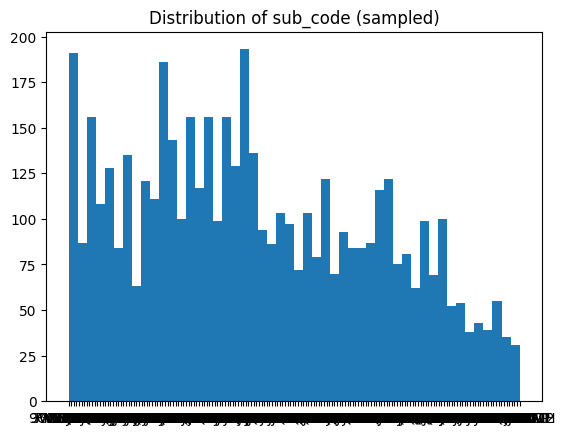

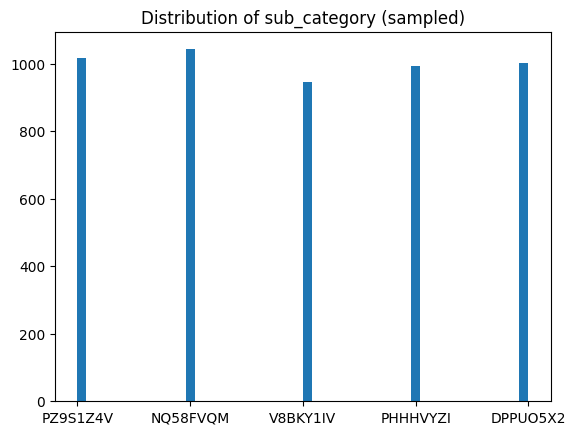

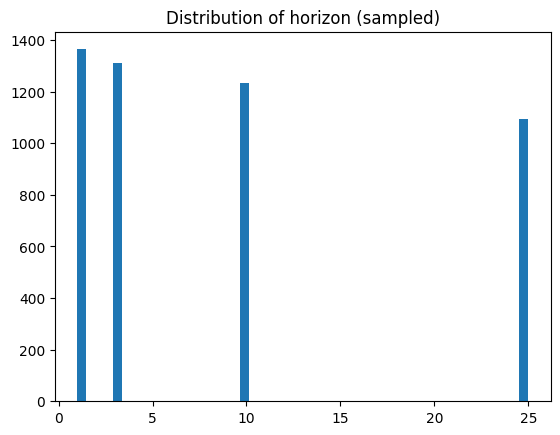

In [6]:
sample_df = train_df.select(num_cols[1:4]).sample(5000)

for col in num_cols[1:4]:
    values = sample_df[col].to_numpy()

    plt.figure()
    plt.hist(values, bins=50)
    plt.title(f"Distribution of {col} (sampled)")
    plt.show()

Volatility Check

In [7]:
# Rolling Volatility
train_df = train_df.with_columns([
    pl.col("y_target")
    .rolling_std(window_size=10)
    .over("code")
    .alias("y_volatility")
])

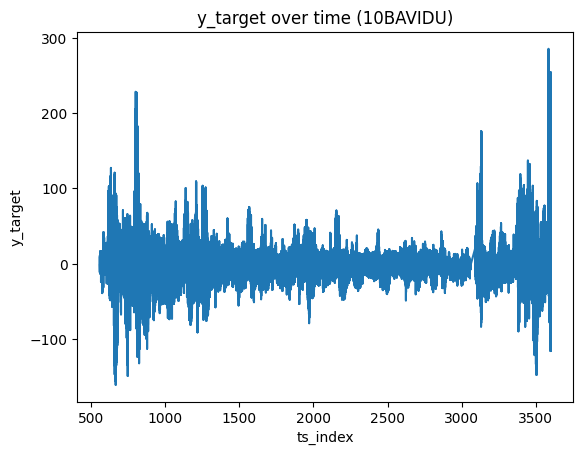

In [8]:
sample_code = train_df.select("code").unique().to_series()[0]

sample_df = (
    train_df
    .filter(pl.col("code") == sample_code)
    .sort("ts_index")
)

plt.figure()
plt.plot(sample_df["ts_index"], sample_df["y_target"])
plt.title(f"y_target over time ({sample_code})")
plt.xlabel("ts_index")
plt.ylabel("y_target")
plt.show()


In [9]:
train_df = train_df.with_columns([
    pl.col("y_target")
    .rolling_mean(window_size=10)
    .over("code")
    .alias("y_rolling_mean")
])
train_df.sample(10)

id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight,y_volatility,y_rolling_mean
str,str,str,str,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""EP12UF2K__U3UOH3XI__V8BKY1IV__…","""EP12UF2K""","""U3UOH3XI""","""V8BKY1IV""",3.0,3558,68.0,10.63358,10.619227,5.713102,2.752094,15.703225,11.3073,0.000234,0.006035,0.002147,0.00036,0.127528,2.61168,-0.010974,0.000206,0.000326,0.000299,0.008351,0.023361,0.001178,0.000705,0.024814,22.472471,6.088396,16.689306,243.567912,0.084582,0.067811,0.054301,1.544218,0.000259,…,10972.107186,65233.762217,572415.15293,2.1121e6,771110.2132,0.003103,144201.679735,0.013216,209.718977,265.726314,84.285158,0.006724,0.453376,0.018595,2.539237,188.556615,5.833318,-0.381055,-7.123449,-0.155473,0.033236,0.264378,10.367426,-0.000044,-0.000039,-0.000035,-0.000038,-0.000013,-0.00088,null,null,1.823487,0.0,0.005476,6.2764e6,0.011563,-0.004867
"""2RBMUWP1__IWOBFO69__PZ9S1Z4V__…","""2RBMUWP1""","""IWOBFO69""","""PZ9S1Z4V""",25.0,2571,44.0,13.747342,6.429336,10.182217,1.12067,3.043807,16.698723,0.00015,0.000166,0.000522,0.000006,1.504444,0.090145,0.029502,0.0,0.097857,0.088272,0.148357,0.060344,0.14283,0.322351,0.210693,35.593377,2.969639,1.338639,5.880055,0.0,0.124903,0.072524,0.039102,0.925924,…,49.723908,274.614572,21717.384476,30961.350525,25063.122035,-0.000994,954095.019889,0.0,0.0,194.363152,0.005259,10.652783,11.528298,7.36544,0.013716,0.008332,0.015282,-0.201795,-7.243056,-3.252203,0.142953,0.090883,0.252664,-0.017931,-0.020961,-0.263136,-0.006562,-0.275804,-0.011367,-0.003216,0.084664,0.064478,1.0,3.466492,1.64999,4.831978,0.357188
"""SJZP0OVU__TIB0QL9Q__PZ9S1Z4V__…","""SJZP0OVU""","""TIB0QL9Q""","""PZ9S1Z4V""",1.0,330,44.0,13.819661,14.651235,1.780755,5.047586,6.364335,11.65839,0.001029,0.00695,0.000118,0.004356,4.219319,0.069594,-0.000049,0.0,0.0,0.000052,0.000856,0.017583,0.019594,0.00372,0.00514,-17.03133,35.860879,75.47481,-264.268045,0.0,0.0,0.122262,0.005743,0.000017,…,5941.851104,162.344687,18971.549367,749313.58088,388829.181964,0.004644,1.1834e6,9.125174,10231.756074,13506.96841,0.866393,0.624249,0.147701,0.688662,2.088053,3.898909,3.415573,-10.080956,-6.523826,-3.029801,0.047626,6.50523,0.271611,-0.000306,-0.003408,-0.00081,-0.000041,-0.002661,-0.000916,-0.000697,4.278118,3.372886,1.0,-0.000266,1.3827e7,0.001691,-0.000393
"""EP12UF2K__FECMBC0A__V8BKY1IV__…","""EP12UF2K""","""FECMBC0A""","""V8BKY1IV""",3.0,2547,50.0,7.505152,1.61216,9.898381,12.738861,7.049762,4.480627,0.000273,0.007033,0.002557,0.000388,0.138328,3.229085,0.00531,0.000103,0.000222,0.000246,0.006103,0.001374,0.00103,0.000837,0.020956,8.988988,-0.329102,5.135171,97.427165,0.032136,0.035103,0.033855,0.857476,0.000229,…,35048.451443,27594.044629,482957.445212,1.7820e6,650600.209722,0.069009,141614.093589,0.809626,25074.000857,518.594903,102.959452,0.004399,0.298225,0.012834,5.054244,355.645484,10.478578,-0.381856,-7.458237,-0.169269,0.032682,0.250535,10.036908,-0.000029,-0.000028,-0.000029,-0.000025,-0.000009,-0.000719,null,null,1.42927,0.0,-0.000256,1.0482e7,0.005495,0.001159
"""SJZP0OVU__8UKRP42K__NQ58FVQM__…","""SJZP0OVU

In [10]:
# Feature Importance Correlation
corr_df = train_df.select(
    [pl.corr(col, "y_target").alias(col) for col in num_cols[:10]]
)

print(corr_df)

shape: (1, 10)
┌─────┬──────────┬──────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ id  ┆ sub_code ┆ sub_category ┆ horizon   ┆ … ┆ feature_c ┆ feature_d ┆ feature_e ┆ feature_f │
│ --- ┆ ---      ┆ ---          ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ f64 ┆ f64      ┆ f64          ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞═════╪══════════╪══════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ NaN ┆ NaN      ┆ NaN          ┆ -0.018719 ┆ … ┆ 0.00057   ┆ 0.000097  ┆ -0.000574 ┆ -0.000027 │
└─────┴──────────┴──────────────┴───────────┴───┴───────────┴───────────┴───────────┴───────────┘


In [11]:
#df = df.sort_values(["code", "sub_code", "sub_category", "ts_index"]) fix
#sklearn.ensemble import RandomForestRegressor model = RandomForestRegressor(n_estimators=100, random_state=42)

# Baseline Model

In [12]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

import warnings
warnings.filterwarnings("ignore")

SEED = 42

print(train_df.shape)
train_df.head()

(5337414, 96)


id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight,y_volatility,y_rolling_mean
str,str,str,str,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""10BAVIDU__XQ1K5P1N__PHHHVYZI__…","""10BAVIDU""","""XQ1K5P1N""","""PHHHVYZI""",25.0,559,188.0,11.389729,12.588061,10.404994,15.626055,15.581696,11.889052,0.016028,0.00018,0.002491,0.000328,3.280671,0.93198,-0.342848,2.92877,0.196527,3.625662,0.246503,3.526996,12.960801,1.230468,0.316888,76.419317,-11.059281,80.277225,-130.885958,0.037743,0.055747,0.014956,1.28225,0.217366,…,0.102742,0.0,15914.608216,27834.04567,17526.640947,0.003154,5048.877691,10.168377,0.0,0.0,0.200791,1325.901342,878.981338,1238.864149,0.001384,0.086726,0.020457,-2.20044,-4.815959,-3.208322,0.035501,0.086964,0.256307,-0.175529,-0.023008,-0.014431,-0.216899,-0.245611,-0.009655,-0.154182,0.049319,0.061914,3.0,-10.330326,0.008653,null,null
"""10BAVIDU__XQ1K5P1N__PHHHVYZI__…","""10BAVIDU""","""XQ1K5P1N""","""PHHHVYZI""",10.0,559,203.0,13.892618,3.446661,5.015149,9.801106,15.570833,8.233758,0.016028,0.00018,0.002491,0.000328,3.280671,0.93198,-0.342848,2.92877,0.196527,3.625662,0.246503,3.526996,12.960801,1.230468,0.316888,76.419317,-11.059281,80.277225,-130.885958,0.037743,0.055747,0.014956,1.28225,0.217366,…,0.102742,0.0,15914.608216,27834.04567,17526.640947,0.003154,5048.877691,10.168377,0.0,0.0,0.200791,1325.901342,878.981338,1238.864149,0.001384,0.086726,0.020457,-2.20044,-4.815959,-3.208322,0.035501,0.086964,0.256307,-0.175529,-0.023008,-0.014431,-0.216899,-0.245611,-0.009655,-0.154182,0.049319,0.061914,3.0,10.613489,0.009727,null,null
"""10BAVIDU__XQ1K5P1N__NQ58FVQM__…","""10BAVIDU""","""XQ1K5P1N""","""NQ58FVQM""",25.0,559,188.0,12.236488,16.029172,16.260251,12.173374,6.713691,13.257354,0.016028,0.00018,0.002491,0.000328,3.280671,0.93198,-0.342848,2.92877,0.196527,3.625662,0.246503,3.526996,12.960801,1.230468,0.316888,76.419317,-11.059281,80.277225,-130.885958,0.037743,0.055747,0.014956,1.28225,0.217366,…,0.102742,0.0,15914.608216,27834.04567,17526.640947,0.003154,5048.877691,10.168377,0.0,0.0,0.200791,1325.901342,878.981338,1238.864149,0.001384,0.086726,0.020457,-2.20044,-4.815959,-3.208322,0.035501,0.086964,0.256307,-0.175529,-0.023008,-0.014431,-0.216899,-0.245611,-0.009655,-0.154182,0.049319,0.061914,3.0,-1.668646,0.028226,null,null
"""10BAVIDU__XQ1K5P1N__NQ58FVQM__…","""10BAVIDU""","""XQ1K5P1N""","""NQ58FVQM""",3.0,559,209.0,10.88399,11.273574,16.472052,9.494337,11.923079,14.383699,0.016028,0.00018,0.002491,0.000328,3.280671,0.93198,-0.342848,2.92877,0.196527,3.625662,0.246503,3.526996,12.960801,1.230468,0.316888,76.419317,-11.059281,80.277225,-130.885958,0.037743,0.055747,0.014956,1.28225,0.217366,…,0.102742,0.0,15914.608216,27834.04567,17526.640947,0.003154,5048.877691,10.168377,0.0,0.0,0.200791,1325.901342,878.981338,1238.864149,0.001384,0.086726,0.020457,-2.20044,-4.815959,-3.208322,0.035501,0.086964,0.256307,-0.175529,-0.023008,-0.014431,-0.216899,-0.245611,-0.009655,-0.154182,0.049319,0.061914,3.0,-0.076996,0.053946,null,null
"""10BAVIDU__XQ1K5P1N__V8BKY1IV__…","""10BAVIDU""","""XQ1K5P1N""","""V

First, the necessary libraries and modles are imported for the creation of this base model which includes using Random Forest Regressor. The preprocessed data is also checked before defining features and target.

In [13]:
TARGET = "horizon"
TS_INDEX = "ts_index"

# Sort by time index
train_df = train_df.sort(TS_INDEX)

# Features
FEATURES = [c for c in train_df.columns if c not in [TARGET, TS_INDEX]]

X = train_df.select(FEATURES)
y = train_df.select(TARGET)

The features and target are selected, now time-series validation splits are  defined to prevent data leakage.

---



In [14]:
# Time-series cross validation
N_SPLITS = 5

tscv = TimeSeriesSplit(n_splits=N_SPLITS)

splits = list(tscv.split(X))

print(f"Number of splits: {len(splits)}")

Number of splits: 5
